In [2]:
import pandas as pd
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Here we extract the DR14 mass catalog from https://sites.utu.fi/sdssdr14/.  These are virial black hole mass estimates.  The data is packaged in a .fits file easily extracted with astropy.

In [7]:
# insert proper path
# catalog downloaded from 
# FILE_PATH = '/Users/SnehPandya/Desktop/DeepLearningAGN/data/dr14q_spec_prop_ext.fits'
FILE_PATH = '/Users/baseb/Desktop/Uni files/DLiP/DLiP_project/data/dr14q_spec_prop_ext.fits'
dr14 = fits.open(FILE_PATH)

In [8]:
DATA = dr14[1].data

In [9]:
# extract relevant data
SDSS_ID = DATA.field('SDSS_ID') # identification
RA = DATA.field('RA') # radial ascension (RA) coordinate  
DEC = DATA.field('DEC')# declination (DEC) coordinate
MASS = DATA.field('LOG_MBH') # virial SMBH mass estimate (LOG)
ERR = DATA.field('LOG_MBH_ERR') # error for mass (LOG)
Z = DATA.field('REDSHIFT') # AGN redshift
MI = DATA.field('MI') # K-corrected i-band magnitude

In [10]:
# make dataframe

def to_numeric(s):
    try:
        return pd.to_numeric(s, errors='raise')
    except ValueError:
        return s

# df = pd.DataFrame(SDSS_ID, columns=['SDSS_ID'])
# df['ID'] = SDSS_ID
# df['ra'] = RA
# df['dec'] = DEC
# df['Mass'] = MASS
# df['z'] = Z
# df['ERR'] = ERR
# df['M_i'] = MI
# df = df.apply(to_numeric)
# df.shape

In [11]:
df = pd.DataFrame({
    "SDSS_ID": np.array(SDSS_ID),
    "ID": np.array(SDSS_ID),
    "ra": np.array(RA),
    "dec": np.array(DEC),
    "Mass": np.array(MASS),
    "z": np.array(Z),
    "ERR": np.array(ERR),
    "M_i": np.array(MI),
})

In [12]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        arr = df[col].to_numpy()
        if arr.dtype.byteorder == ">":
            df[col] = arr.byteswap().view(arr.dtype.newbyteorder("="))

In [13]:
print(df['Mass'].head(10))
print(df['Mass'].dtype)

# df["Mass"] = df["Mass"].astype('float64')
# arr = df["Mass"].to_numpy()
# df["Mass"] = pd.Series(
#     arr.byteswap().view(arr.dtype.newbyteorder("=")),
#     index=df.index
# )

0    8.676115
1    8.744595
2    8.183135
3    8.360200
4    9.576048
5    9.332618
6    8.826519
7    8.683706
8    8.657381
9    9.225701
Name: Mass, dtype: float64
float64


In [14]:
print(df['Mass'].describe()['count'])

526265.0


Some of these black hole masses have very high errors or unphysical mass estimations.  Large uncertainites in the ground truth is not good for training, so here we filter mass estimates with large errors.

In [15]:
# drop unphysical estimates or NaN
df = df.dropna()
df = df[df['Mass'] > 0]

In [16]:
clean_df = df[df['ERR']<.3] # filter BH mass estimates with error < .3 dex
clean_df.shape

(417618, 8)

You can see we lost roughly ~100,000 AGN through our cleaning process. Now to visualize our data.  This plot shows the location on the sky of the observed AGN.

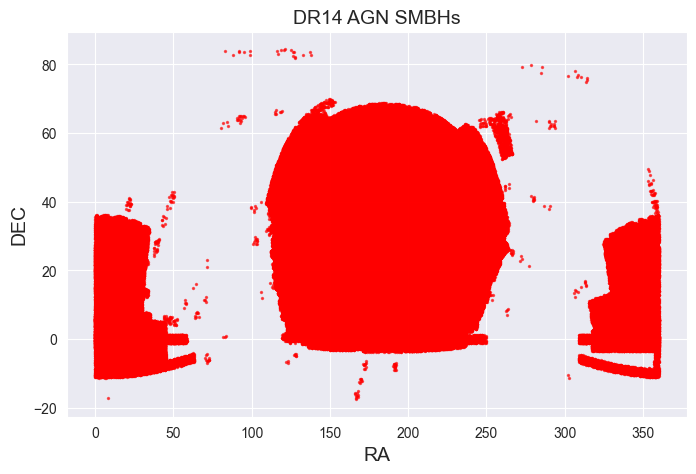

In [17]:
sns.set_style('darkgrid')
plt.figure(figsize = [8,5])
plt.title('DR14 AGN SMBHs',fontsize=14)
plt.xlabel('RA',fontsize=14)
plt.ylabel('DEC',fontsize=14)
plt.scatter(clean_df['ra'], clean_df['dec'], color = 'red', s=2, alpha=.6)

Now we'd like to know how our masses and errors are distributed.

<>:5: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:5: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\baseb\AppData\Local\Temp\ipykernel_17652\1260070927.py:5: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('AGN SMBH Mass [$log(M_{SMBH}/M_{\odot})$]',  fontsize=14)
C:\Users\baseb\AppData\Local\Temp\ipykernel_17652\1260070927.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/

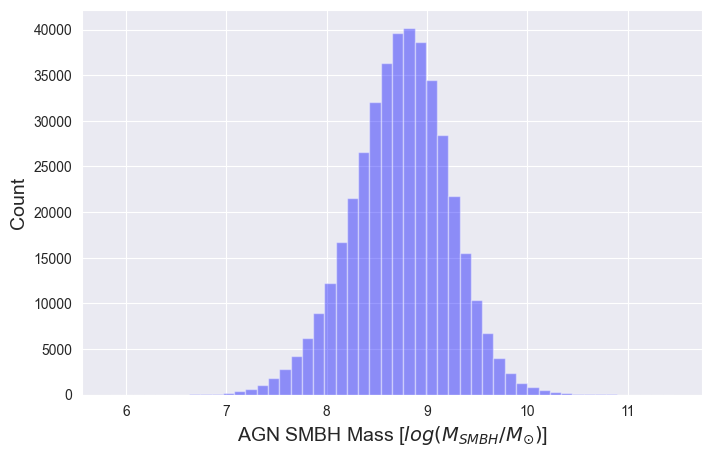

In [18]:
plt.figure(figsize=(8, 5))
sns.distplot(clean_df['Mass'], kde=False, color='blue')
# plt.title('Ground Truth Mass Distribution',  fontsize=14)
# plt.xlim(0,.3)
plt.xlabel('AGN SMBH Mass [$log(M_{SMBH}/M_{\odot})$]',  fontsize=14)
plt.ylabel('Count',  fontsize=14)
plt.savefig('/Users/baseb/Desktop/Uni files/DLiP/DLiP_project/data/mass_hist.pdf', bbox_inches = 'tight',
    pad_inches = 0)

Let's also see how what our ground truth redshift distribution is.

C:\Users\baseb\AppData\Local\Temp\ipykernel_17652\634441952.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['z'], kde=False, color='red')


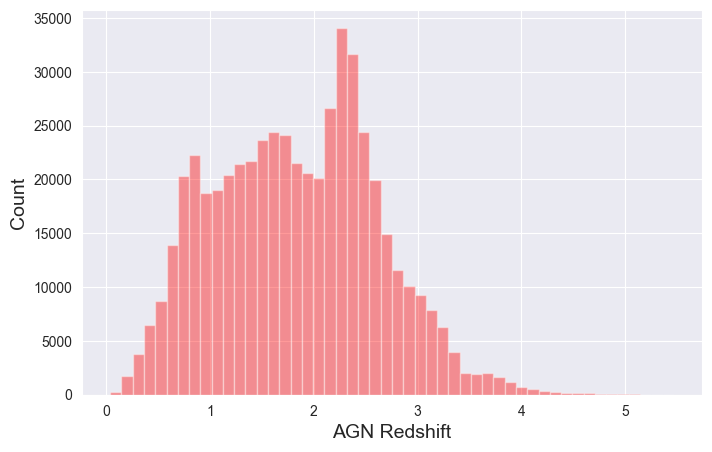

In [19]:
plt.figure(figsize=(8, 5))
sns.distplot(df['z'], kde=False, color='red')
# plt.title('Ground Truth Mass Distribution',  fontsize=14)
# plt.xlim(0,.3)
plt.xlabel('AGN Redshift',  fontsize=14)
plt.ylabel('Count',  fontsize=14)
plt.savefig('/Users/baseb/Desktop/Uni files/DLiP/DLiP_project/data/z_hist.pdf', bbox_inches = 'tight',
    pad_inches = 0)

C:\Users\baseb\AppData\Local\Temp\ipykernel_17652\88534114.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clean_df['ERR'], kde=False, color='red')


Text(0, 0.5, 'Count')

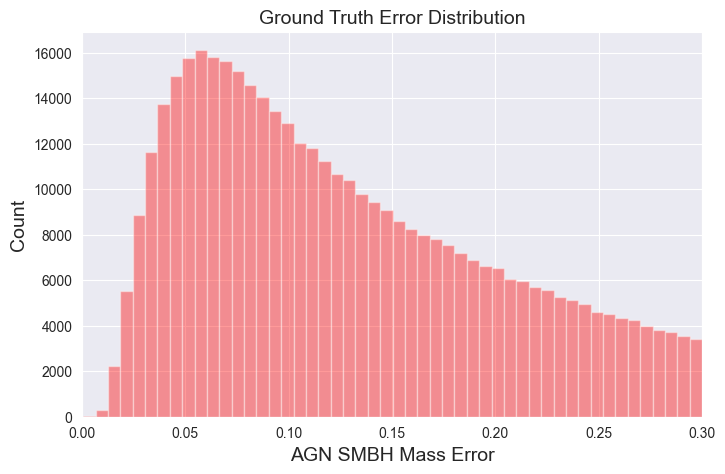

In [20]:
plt.figure(figsize=(8, 5))
sns.distplot(clean_df['ERR'], kde=False, color='red')
plt.title('Ground Truth Error Distribution',  fontsize=14)
plt.xlim(0,.3)
plt.xlabel('AGN SMBH Mass Error',  fontsize=14)
plt.ylabel('Count',  fontsize=14)

Now for our mass distribution as a function of redshift. The apparent break at z~2 is an artifict of survey design.

Text(0.5, 1.0, 'DR14 AGN')

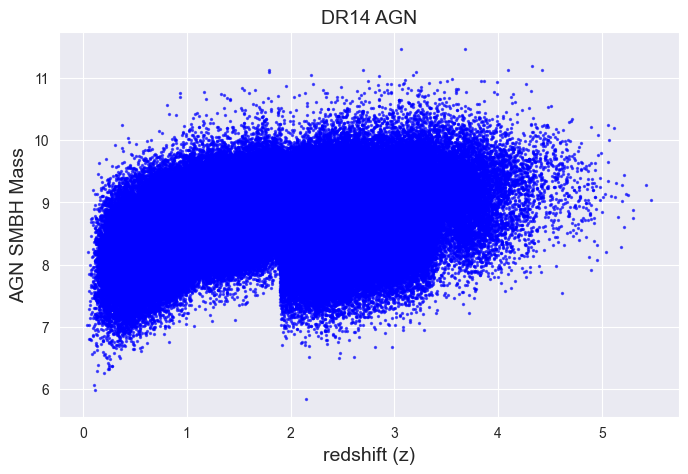

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df['z'],clean_df['Mass'], s=2, color = 'blue', alpha=.6)
plt.xlabel('redshift (z)', fontsize= 14)
plt.ylabel('AGN SMBH Mass', fontsize=14)
plt.title('DR14 AGN', fontsize=14)

This process can be repeated with the DR7 .fits file from (http://quasar.astro.illinois.edu/BH_mass/dr7.htm)

In [ ]:
# output csv
# clean_df.to_csv('/Users/baseb/Desktop/Uni files/DLiP/DLiP_project/data/dr14_BH.csv', index=False)

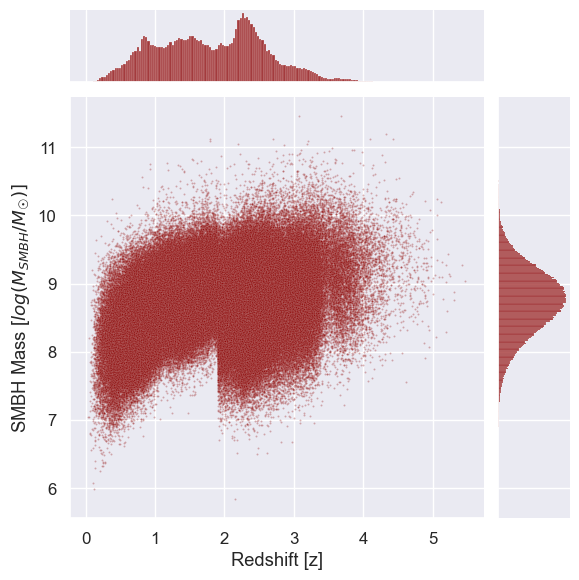

In [24]:
sns.set(font_scale=1.1)
fig = sns.jointplot(
    data=clean_df,
    x="z",
    y="Mass",
    s=2,
    alpha=0.3,
    color="darkred"
)
fig.set_axis_labels('Redshift [z]', "SMBH Mass [$log(M_{SMBH}/M_{☉})]$")
fig.savefig('/Users/baseb/Desktop/Uni files/DLiP/DLiP_project/data/cleandfplot.png', dpi=300)

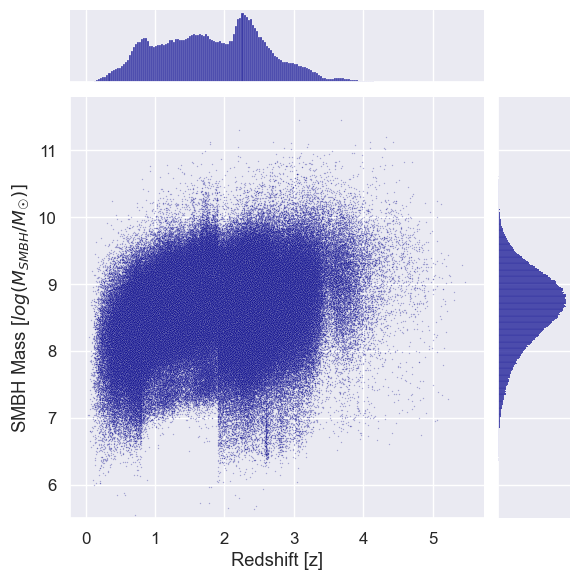

In [25]:
sns.set(font_scale=1.1)
fig = sns.jointplot(
    data=df,
    x="z",
    y="Mass",
    s=1,
    alpha=0.3,
    color="darkblue"
)
fig.set_axis_labels('Redshift [z]', "SMBH Mass [$log(M_{SMBH}/M_{☉})]$")
fig.ax_marg_y.set_ylim(5.5, 11.8)
fig.savefig('/Users/baseb/Desktop/Uni files/DLiP/DLiP_project/data/dfplot.png', dpi=300)